Standard Neural Networks (NNs) generally fail at solving even simple linear PDEs. PINNs use NNs and incorporate the PDE inside the

loss function, as we will see a few steps later.

In some sense, PINNs are "semi-supervised" meaning that the equation drives the learning process (PINNs are supervised "by the equation").

This repository first shows how NNs fail to learn a simple linear ODE outside the training set.

We train a baseline Neural Network to learn the cosine function for which we, of course, have data.

Then we see this function as the solution to the following differential equation:
$$
\begin{cases}
y'' + y = 0, \\
y(0) = 1, \\
y'(0) = 0
\end{cases}
$$

and use PINNs to solve it.

We import a few packages such as Pytorch, Matplotlib and Numpy:

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset,DataLoader
import numpy as np
import torch.optim
import matplotlib.pyplot as plt
import torch.autograd

We create our training and test data:

we discretize the interval $[0,2\pi]$ uniformly with 201 points.

Then, we split this interval in train set $[0,5]$, and test set $[5,2\pi]$.

In [2]:
mesh = torch.linspace(0,2*np.pi,201)
cos_mesh = torch.cos(mesh)

Plot of the cosine function on $[0,2\pi]$

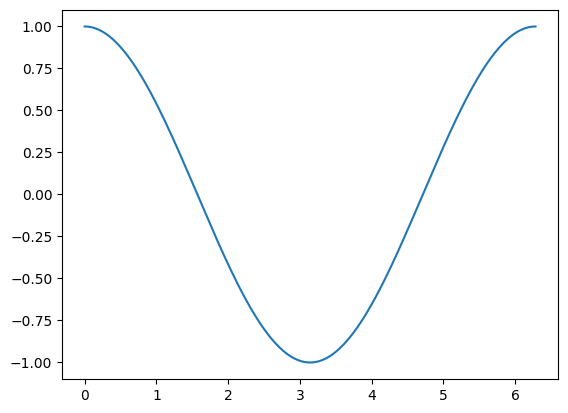

In [3]:
plt.plot(mesh,cos_mesh)
plt.show()

Now we define the mesh on which we are going to learn our NN parameters which is way less dense than the previous one:

In [4]:
mesh_nn = torch.linspace(0,2*np.pi,20)
cos_mesh_nn = torch.cos(mesh_nn)
dataset = torch.stack((mesh_nn,cos_mesh_nn))
nb_train = int(dataset.shape[1]*0.8)
data_train = dataset[:,:nb_train]
data_test = dataset[:,nb_train:]
print(data_train.shape,data_test.shape)

torch.Size([2, 16]) torch.Size([2, 4])


We define our inputs and labels in the getitem method:

In [5]:
class Cosine(Dataset):
    def __init__(self,dataset):
        super().__init__()

        self.dataset = dataset

    def __getitem__(self,idx):
        return self.dataset[0,idx], self.dataset[1,idx]


    def __len__(self):

        return self.dataset.shape[1]   


Regular Neural Network class:

In [6]:
class Neural_Net(nn.Module):
    def __init__(self,nb_layers,input_dim,latent_dim,output_dim,activation):
        super().__init__()

        self.nb_layers = nb_layers
        self.input_dim = input_dim
        self.latent_dim = latent_dim
        self.output_dim = output_dim
        self.activation = activation
        self.layers = nn.ModuleList([nn.Linear(input_dim,latent_dim)])
        for i in range(self.nb_layers-1):
            self.layers.append(nn.Linear(latent_dim,latent_dim))

        self.last_layer = nn.Linear(latent_dim,output_dim)    

    def forward(self,x):

        inputs = [x]
        for j in range(self.nb_layers):
            a = self.layers[j](inputs[j])
            b = self.activation(a)
            
            inputs.append(b)
        
        output = self.last_layer(inputs[-1])
        return output      


In [7]:
cos_train = Cosine(dataset=data_train)
cos_test = Cosine(dataset=data_test)
BATCH_SIZE = 4
N_EPOCHS = 5000
LR = 1e-3
INPUT_DIM = 1
LATENT_DIM = 20
OUTPUT_DIM = 1
activation = nn.Tanh()
NB_LAYERS = 3
EVERY_EP = 200
ALPHA = 0.1

Here is our NN model with only 2 hidden layers:

In [8]:
NN = Neural_Net(nb_layers=NB_LAYERS,input_dim=INPUT_DIM,latent_dim=LATENT_DIM,output_dim=OUTPUT_DIM,activation=activation)

In [9]:
optimizer = torch.optim.Adam(NN.parameters(),lr=LR,weight_decay=1e-4)

In [10]:
train_loader = DataLoader(dataset=cos_train,batch_size=BATCH_SIZE,shuffle=True,drop_last=True)
test_loader = DataLoader(dataset=cos_test,batch_size=BATCH_SIZE,shuffle=False,drop_last=False)

We train our baseline NN model with 5000 epochs:

In [11]:
loss_train = 0
l=torch.tensor([0.])
for epoch in range(N_EPOCHS):


    for n_batch,batch in enumerate(train_loader):
        x,labels = batch
        outputs = NN(x.view(BATCH_SIZE,INPUT_DIM))
        
        loss = torch.mean((outputs-labels.view(BATCH_SIZE,INPUT_DIM))**2)
           

        loss_train += loss.detach()
        
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

    loss_train /= (len(train_loader.dataset))
    loss_train *= BATCH_SIZE 
    
    loss_test = 0
    with torch.no_grad():
        for n_batch,batch in enumerate(test_loader):
            a,l =  batch 

            out = NN(a.view(BATCH_SIZE,INPUT_DIM))
            
            Loss = torch.mean((out-l)**2)    
            loss_test += Loss.detach()
        loss_test /= (len(test_loader.dataset)) 
        loss_test *= BATCH_SIZE       
        
        if epoch%EVERY_EP == 0:
            print(f"Epoch: {epoch} , Loss Train: {loss_train}, Loss Test: {loss_test}")



Epoch: 0 , Loss Train: 0.47198018431663513, Loss Test: 1.0426721572875977
Epoch: 200 , Loss Train: 0.020767150446772575, Loss Test: 0.24600864946842194
Epoch: 400 , Loss Train: 0.0016160942614078522, Loss Test: 0.1413532942533493
Epoch: 600 , Loss Train: 0.000207995341042988, Loss Test: 0.19804765284061432
Epoch: 800 , Loss Train: 0.000241904504946433, Loss Test: 0.2127722203731537
Epoch: 1000 , Loss Train: 0.00039967187331058085, Loss Test: 0.21904835104942322
Epoch: 1200 , Loss Train: 9.844238229561597e-05, Loss Test: 0.20901630818843842
Epoch: 1400 , Loss Train: 0.00016479908663313836, Loss Test: 0.20752620697021484
Epoch: 1600 , Loss Train: 0.0002571004442870617, Loss Test: 0.1960185021162033
Epoch: 1800 , Loss Train: 0.0002997493138536811, Loss Test: 0.18103434145450592
Epoch: 2000 , Loss Train: 0.010093683376908302, Loss Test: 0.2000776082277298
Epoch: 2200 , Loss Train: 7.745542097836733e-05, Loss Test: 0.18337951600551605
Epoch: 2400 , Loss Train: 7.676115637877956e-05, Loss Te

We see that the model learns well on the training data (Loss:  $6.10{-5}$), but does not have good performances on the test set (Loss:  $0.12$)

We visualize this error here under and notice that the model starts to diverge from the ground truth in the test set:

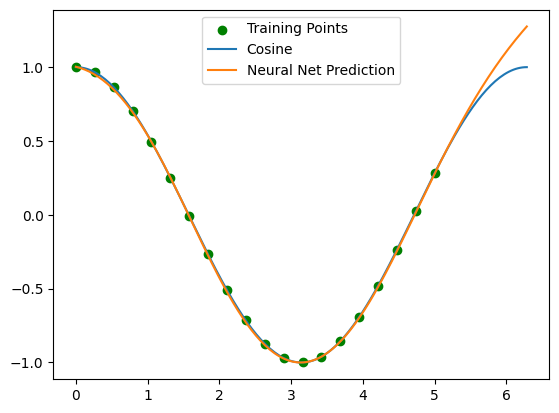

In [12]:
import matplotlib.pyplot as plt

grid = torch.linspace(0,2*np.pi,201).view(201,1)
cos_grid = torch.cos(grid)
y_prediction = NN(grid).detach()
grid_train = torch.linspace(0,5,20).view(20,1)
plt.scatter(grid_train.detach(),torch.cos(grid_train.detach()),color='g',label='Training Points')
plt.plot(grid,cos_grid,label='Cosine')
plt.plot(grid,y_prediction,label='Neural Net Prediction')
plt.legend()



We are now going to learn the Cosine function using a completely different method called

Physics-Informed Neural Networks ($PINNs$):

Consider the following differential equation with two initial conditions:


$y''(x)+ y(x) = 0, x \in [0,2\pi] ,$
            
$y(0) = 1, $
             
$y'(0) = 0$











We know this equation has a unique solution: the cosine.

Neural Networks are universal approximators of continuous functions (on compact sets).

The idea of PINNs is to parameterize $y$ as a Neural Network $y_\theta$ :

thanks to Automatic Differentiation and more particularly the torch.autograd package, we 

can compute the derivative $ \frac{\partial y}{\partial x}$ (that is $y'$), and then $ \frac{\partial^2 y}{\partial x^2}$(that is $y''$) at any point $x$,

 here we choose to evaluate at the points $x_k = \frac{2k\pi}{n} , k \in{0,...,n}$ (and we decide that $n = 14$).

Now let us consider the three following losses:

$L_1 = (y_\theta(0)-1)^2$  

$L_2 = y'_\theta(0)^2$   

$L_3 = (\sum_{k=1}^{n} y''_\theta(x_k) + y_\theta(x_k))^2$ 


Denoting the final loss $L_\theta$, we have:

$L_\theta = \frac{1}{n}(L_1+L_2+L_3)$

and we will minimize $|L_\theta|$ in order to get a solution that respects this differential equation.

In [13]:
Physics_NN = Neural_Net(nb_layers=2,input_dim=1,latent_dim=30,output_dim=1,activation=activation)

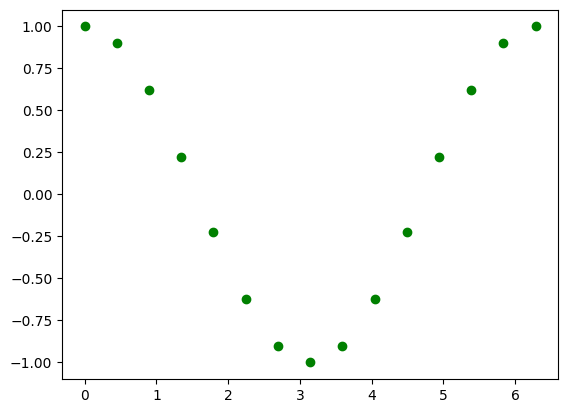

In [14]:
physics_optimizer = torch.optim.Adam(Physics_NN.parameters(),lr=LR)
criterion = nn.MSELoss()
nb_points = 15
x_15 = torch.linspace(0,2*np.pi,nb_points).view(nb_points,1).requires_grad_()
plt.scatter(x_15.detach(),torch.cos(x_15.detach()),color='green')


Here under, we learn the parameters $\theta$ : we expect to get a prediction that respects both the differential equation,

and the initial conditions, thus should give a correct approximation of the cosine.

In [15]:
for ep in range(N_EPOCHS):
    
        
    y = Physics_NN(x_15)
    dy_dx = torch.autograd.grad(y,x_15,torch.ones_like(y),create_graph=True)[0] ###first derivative of y w.r.t x
    
    dy_dxx = torch.autograd.grad(dy_dx,x_15,torch.ones_like(dy_dx),create_graph=True)[0] ### second derivative of y w.r.t x
    loss_ic_y = (y[0]-1)**2   ### ic stands for initial condition, initial condition y(0) = 1
    loss_ic_dy = (dy_dx[0])**2   ### initial condition on the first derivative y'(0) = 0
    loss_physics = (dy_dxx+y)**2    ### we define y''+ y  
    loss = loss_ic_y + loss_ic_dy + torch.mean(loss_physics)
        
    loss.backward()
    physics_optimizer.step()  ### we minimize the sum of loss_physics and the two ic's so that the Differential Equation loss is small and also the IC terms are small
    physics_optimizer.zero_grad()   
     

    if ep%100==0:
        print('loss',loss.item(),'epoch',ep)

loss 0.9075949192047119 epoch 0
loss 0.0908515602350235 epoch 100
loss 0.08258990943431854 epoch 200
loss 0.07646938413381577 epoch 300
loss 0.06575540453195572 epoch 400
loss 0.05066394433379173 epoch 500
loss 0.03439388424158096 epoch 600
loss 0.02513069100677967 epoch 700
loss 0.021552799269557 epoch 800
loss 0.019733771681785583 epoch 900
loss 0.018345342949032784 epoch 1000
loss 0.01670941710472107 epoch 1100
loss 0.015125984326004982 epoch 1200
loss 0.014092233963310719 epoch 1300
loss 0.01324799470603466 epoch 1400
loss 0.012462073005735874 epoch 1500
loss 0.01166549138724804 epoch 1600
loss 0.010783176869153976 epoch 1700
loss 0.009764189831912518 epoch 1800
loss 0.008590844459831715 epoch 1900
loss 0.0072706895880401134 epoch 2000
loss 0.005832855589687824 epoch 2100
loss 0.004332287237048149 epoch 2200
loss 0.0028508442919701338 epoch 2300
loss 0.0015564091736450791 epoch 2400
loss 0.0007957753259688616 epoch 2500
loss 0.000473526306450367 epoch 2600
loss 0.000307506852550432

In the beggining we only had $15$ 'equation' points. Below we discretize more densely ($500$ points).

 We do not see any difference between the true Cosine function and the NN's prediction.

With only $15$ 'equation' points, the Physics-Informed Neural Network method performs very well.

We do not need many points to obtain a good result (at least in dimension $1$).

C:\Users\jamja\AppData\Local\Temp\ipykernel_17084\1249655451.py:3: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  cos_grid = np.cos(grid)


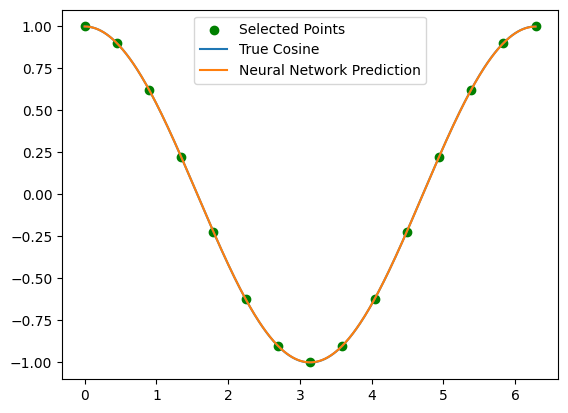

In [16]:
x = torch.linspace(0,2*np.pi,500).view(500,1).requires_grad_()
grid = x.detach()
cos_grid = np.cos(grid)
y = Physics_NN(x)
physics_prediction = y.detach()

plt.scatter(x_15.detach(),torch.cos(x_15.detach()),color='green',label='Selected Points')
plt.plot(grid,cos_grid,label='True Cosine')
plt.plot(grid,physics_prediction,label='Neural Network Prediction')
plt.legend()


We can compute the Mean Squared Error between our $NN$ prediction and the true solution:

the error is around $3.10^{-6}$ which is very low.

In [17]:
print('Mean Square Error',criterion(physics_prediction,torch.cos(grid)).item())

Mean Square Error 2.335098514549827e-07


We can show the  first and second derivative of the cosine against the  

first and second derivative of the NN.
We see that the approximation 

is very good for both the first and second derivative.

Error on the first derivative: $4.10{-7}$ 

Error on the second derivative: $1.10{-5}$

In [18]:
dy_dx_graph = torch.autograd.grad(y,x,torch.ones_like(y),create_graph=True)[0]
dy_dxx_graph = torch.autograd.grad(dy_dx_graph,x,torch.ones_like(dy_dx_graph),create_graph=True)[0]
dy_detach = dy_dx_graph.detach()

C:\Users\jamja\AppData\Local\Temp\ipykernel_17084\507453650.py:2: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  plt.plot(grid,-np.sin(grid),label='Negative Sine')
C:\Users\jamja\AppData\Local\Temp\ipykernel_17084\507453650.py:4: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  plt.plot(grid,-np.cos(grid),label = 'Negative cosine')


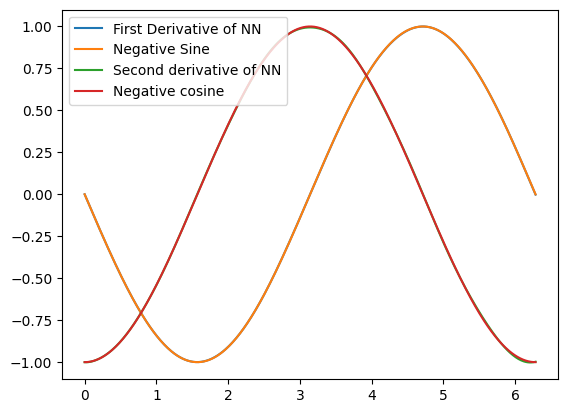

In [19]:
plt.plot(grid,dy_detach,label='First Derivative of NN')
plt.plot(grid,-np.sin(grid),label='Negative Sine')
plt.plot(grid,dy_dxx_graph.detach(),label='Second derivative of NN')
plt.plot(grid,-np.cos(grid),label = 'Negative cosine')
plt.legend()

In [20]:
e1 = criterion(dy_detach,-np.sin(grid))
e2 = criterion(dy_dxx_graph,-np.cos(grid))
print('Error on the first derivative',e1.item())
print('Error on the 2nd derivative',e2.item())

Error on the first derivative 4.579192989240255e-07
Error on the 2nd derivative 1.10033306555124e-05


C:\Users\jamja\AppData\Local\Temp\ipykernel_17084\759927968.py:1: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  e1 = criterion(dy_detach,-np.sin(grid))
C:\Users\jamja\AppData\Local\Temp\ipykernel_17084\759927968.py:2: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  e2 = criterion(dy_dxx_graph,-np.cos(grid))
